# Representation Learning with Autoencoders (AE & VAE)

This notebook implements:
- Autoencoder (AE) for image reconstruction
- Variational Autoencoder (VAE) for probabilistic representation learning
- Latent space visualization
- Image generation from latent space
- Denoising autoencoder

Dataset: MNIST (28x28 grayscale images)

## 1. Environment Setup

- Enable GPU
- Mount Google Drive
- Create project structure

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base_path = "/content/drive/MyDrive/AE_VAE_Assignment"

os.makedirs(base_path + "/models", exist_ok=True)
os.makedirs(base_path + "/utils", exist_ok=True)
os.makedirs(base_path + "/experiments", exist_ok=True)

## 2. Data Loading & Preprocessing

- Load MNIST dataset
- Normalize pixel values to [0,1]
- Convert data into tf.data pipeline

In [ ]:
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test  = x_test.astype("float32") / 255.

In [ ]:
import tensorflow as tf

def preprocess(x):
    x = tf.expand_dims(x, -1)  # (28,28,1)
    return x, x

def make_dataset(x, batch_size=128):
    ds = tf.data.Dataset.from_tensor_slices(x)
    ds = ds.map(preprocess)
    ds = ds.shuffle(10000)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(x_train)
test_ds  = make_dataset(x_test)

## 3. Autoencoder (AE)

The Autoencoder consists of:
- Encoder: compress input into latent representation
- Decoder: reconstruct image from latent vector

Objective: minimize reconstruction error

In [ ]:
from tensorflow.keras import layers, Model

class AE(Model):
    def __init__(self, latent_dim=64):
        super().__init__()

        self.encoder = tf.keras.Sequential([
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dense(latent_dim)
        ])

        self.decoder = tf.keras.Sequential([
            layers.Dense(128, activation='relu'),
            layers.Dense(28*28, activation='sigmoid'),
            layers.Reshape((28,28,1))
        ])

    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [ ]:
ae = AE()

ae.compile(optimizer='adam', loss='mse')

history = ae.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0380 - val_loss: 0.0169
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0140 - val_loss: 0.0113
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0104 - val_loss: 0.0091
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0087 - val_loss: 0.0078
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0077 - val_loss: 0.0069
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0069 - val_loss: 0.0063
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0063 - val_loss: 0.0060
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0059 - val_loss: 0.0056
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0056 - val_loss: 0.0052
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0053 - val_loss: 0.0051


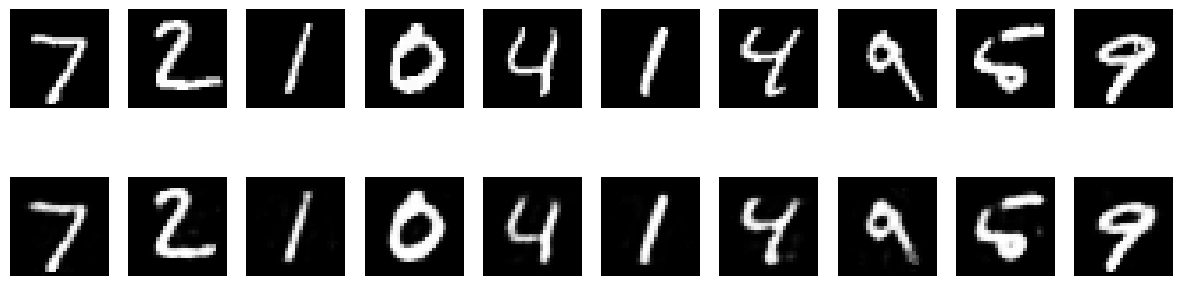

In [ ]:
import matplotlib.pyplot as plt

sample = x_test[:10]
sample = tf.expand_dims(sample, -1)

reconstructed = ae(sample)

plt.figure(figsize=(15,4))
for i in range(10):
    # original
    plt.subplot(2,10,i+1)
    plt.imshow(sample[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')

    # reconstructed
    plt.subplot(2,10,i+11)
    plt.imshow(reconstructed[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')

### 3.2 Latent Space Visualization (AE)

Visualize 2D latent space learned by the Autoencoder

In [ ]:
ae_2d = AE(latent_dim=2)

ae_2d.compile(optimizer='adam', loss='mse')

ae_2d.fit(train_ds, validation_data=test_ds, epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0658 - val_loss: 0.0547
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0521 - val_loss: 0.0500
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0491 - val_loss: 0.0483
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0478 - val_loss: 0.0472
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0467 - val_loss: 0.0461
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0457 - val_loss: 0.0454
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0449 - val_loss: 0.0447
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0443 - val_loss: 0.0441
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0438 - val_loss: 0.0437
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0434 - val_loss: 0.0434


Text(0.5, 1.0, 'Latent Space (AE)')

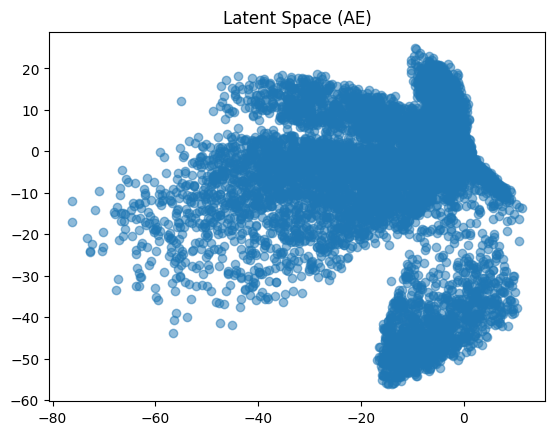

In [ ]:
z = ae_2d.encoder(tf.expand_dims(x_test, -1)).numpy()

plt.scatter(z[:,0], z[:,1], alpha=0.5)
plt.title("Latent Space (AE)")

## 4. Variational Autoencoder (VAE)

Unlike AE, VAE learns:
- Mean (μ)
- Variance (σ²)

Uses reparameterization trick to sample latent variables

In [ ]:
class VAE(Model):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.encoder = tf.keras.Sequential([
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dense(latent_dim * 2)
        ])

        self.decoder = tf.keras.Sequential([
            layers.Dense(128, activation='relu'),
            layers.Dense(28*28, activation='sigmoid'),
            layers.Reshape((28,28,1))
        ])

    def sample(self, mu, log_var):
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * eps

    def call(self, x):
        h = self.encoder(x)
        mu, log_var = tf.split(h, 2, axis=1)

        z = self.sample(mu, log_var)
        x_recon = self.decoder(z)

        return x_recon, mu, log_var

In [ ]:
def vae_loss(x, x_recon, mu, log_var):
    recon = tf.reduce_mean(tf.keras.losses.mse(x, x_recon))

    kl = -0.5 * tf.reduce_mean(
        1 + log_var - tf.square(mu) - tf.exp(log_var)
    )

    return recon + kl

In [ ]:
vae = VAE()
optimizer = tf.keras.optimizers.Adam()

recon_losses = []
kl_losses = []
total_losses = []

for epoch in range(10):
    total_loss = 0
    total_recon = 0
    total_kl = 0
    num_batches = 0

    for x, _ in train_ds:

        with tf.GradientTape() as tape:
            x_recon, mu, log_var = vae(x)

            recon = tf.reduce_mean(tf.keras.losses.mse(x, x_recon))
            kl = -0.5 * tf.reduce_mean(
                1 + log_var - tf.square(mu) - tf.exp(log_var)
            )

            loss = recon + kl

        grads = tape.gradient(loss, vae.trainable_variables)
        optimizer.apply_gradients(zip(grads, vae.trainable_variables))

        total_loss += loss
        total_recon += recon
        total_kl += kl
        num_batches += 1

    avg_loss = total_loss / num_batches
    avg_recon = total_recon / num_batches
    avg_kl = total_kl / num_batches

    total_losses.append(avg_loss.numpy())
    recon_losses.append(avg_recon.numpy())
    kl_losses.append(avg_kl.numpy())

    print(f"""
    Epoch {epoch+1}
    Total Loss: {avg_loss.numpy():.4f}
    Recon Loss: {avg_recon.numpy():.4f}
    KL Loss: {avg_kl.numpy():.4f}
    """)


    Epoch 1
    Total Loss: 0.0875
    Recon Loss: 0.0848
    KL Loss: 0.0026
    

    Epoch 2
    Total Loss: 0.0676
    Recon Loss: 0.0676
    KL Loss: 0.0000
    

    Epoch 3
    Total Loss: 0.0674
    Recon Loss: 0.0674
    KL Loss: 0.0000
    

    Epoch 4
    Total Loss: 0.0674
    Recon Loss: 0.0674
    KL Loss: 0.0000
    

    Epoch 5
    Total Loss: 0.0673
    Recon Loss: 0.0673
    KL Loss: 0.0000
    

    Epoch 6
    Total Loss: 0.0673
    Recon Loss: 0.0673
    KL Loss: 0.0000
    

    Epoch 7
    Total Loss: 0.0673
    Recon Loss: 0.0673
    KL Loss: 0.0000
    

    Epoch 8
    Total Loss: 0.0673
    Recon Loss: 0.0673
    KL Loss: 0.0000
    

    Epoch 9
    Total Loss: 0.0673
    Recon Loss: 0.0673
    KL Loss: 0.0000
    

    Epoch 10
    Total Loss: 0.0673
    Recon Loss: 0.0673
    KL Loss: 0.0000
    


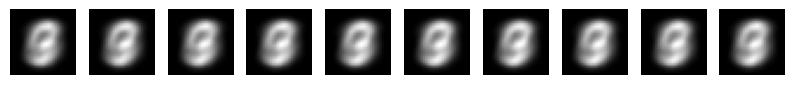

In [ ]:
z = tf.random.normal((10, 2))
generated = vae.decoder(z)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(generated[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')

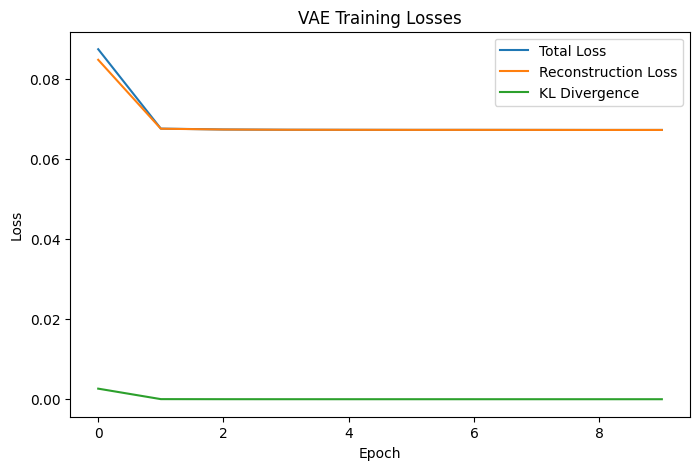

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(total_losses, label="Total Loss")
plt.plot(recon_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Divergence")

plt.legend()
plt.title("VAE Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

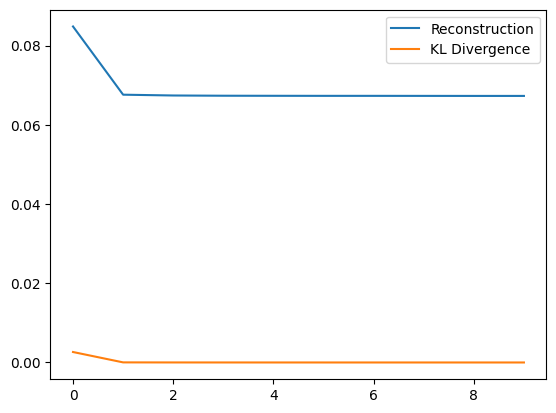

In [ ]:
plt.plot(recon_losses, label="Reconstruction")
plt.plot(kl_losses, label="KL Divergence")
plt.legend()

### 4.4 Latent Space Visualization (VAE)

Observe distribution of latent representations

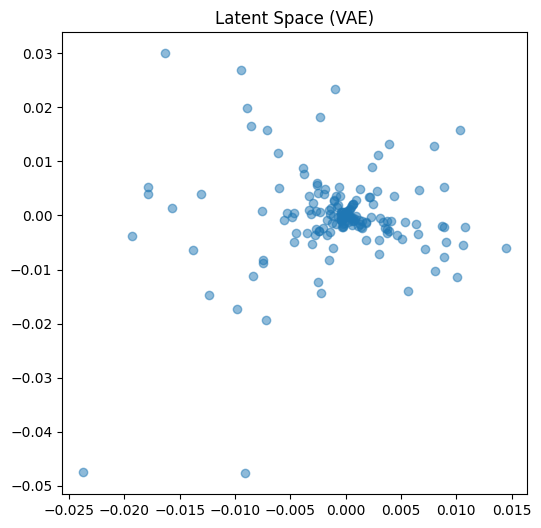

In [ ]:
h = vae.encoder(tf.expand_dims(x_test, -1))
mu, _ = tf.split(h, 2, axis=1)

plt.figure(figsize=(6,6))
plt.scatter(mu[:,0], mu[:,1], alpha=0.5)
plt.title("Latent Space (VAE)")
plt.show()

## 5. Denoising Autoencoder

Train model to:
- Input: noisy image
- Output: clean image

This demonstrates robustness of learned representation

In [ ]:
noise_factor = 0.2

x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy  = x_test  + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, 0., 1.)
x_test_noisy  = tf.clip_by_value(x_test_noisy, 0., 1.)

In [ ]:
train_ds_noisy = make_dataset(x_train_noisy)
ae_denoise = AE()

ae_denoise.compile(optimizer='adam', loss='mse')

ae_denoise.fit(train_ds_noisy, epochs=5)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0421
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0258
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0230
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0217
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0209


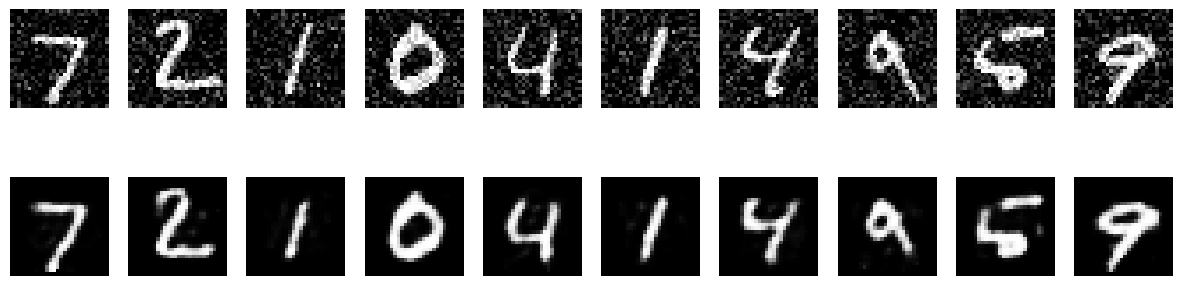

In [ ]:
noisy_sample = tf.expand_dims(x_test_noisy[:10], -1)
denoised = ae_denoise(noisy_sample)

plt.figure(figsize=(15,4))
for i in range(10):
    # noisy
    plt.subplot(2,10,i+1)
    plt.imshow(noisy_sample[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')

    # denoised
    plt.subplot(2,10,i+11)
    plt.imshow(denoised[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')

In [ ]:
ae.save(base_path + "/models/ae_model.keras")
vae.save_weights(base_path + "/models/vae_weights.weights.h5")

## 6. AE vs VAE Comparison

### Reconstruction
- AE produces sharper reconstructions
- VAE produces smoother images

### Generation
- AE cannot generate new meaningful samples
- VAE can generate new data from latent space

### Latent Space
- AE latent space is unstructured
- VAE latent space follows a Gaussian distribution

### Conclusion
VAE is better for generative modeling, while AE is better for reconstruction tasks

In [57]:
# initialize
!git init

# set identity
!git config --global user.email "s-salma.ramzy@zewailcity.edu.eg"
!git config --global user.name "salmaramzyy"

# go to project folder
%cd /content/drive/MyDrive/AE_VAE_Assignment

# init repo here (important)
!git init

# add only project files
!git add .

# commit
!git commit -m "AE & VAE assignment"

Reinitialized existing Git repository in /content/.git/
/content/drive/MyDrive/AE_VAE_Assignment
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/AE_VAE_Assignment/.git/
[master (root-commit) 33d0dff] AE & VAE assignment
 2 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 models/ae_model.keras
 create mode 100644 models/vae_weights.weights.h5
